In [1]:
import mplfinance as mpf
import yfinance as yf
import datetime as dt
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression
import statsmodels.tsa.stattools as ts
from ipywidgets import interact, IntSlider

In [2]:
tickers = ["GC=F", "GLD"]

data = yf.download(tickers, period="3y", interval="1d", group_by='ticker',auto_adjust=True).dropna()
strat = pd.DataFrame(index=data.index)

[*********************100%***********************]  2 of 2 completed


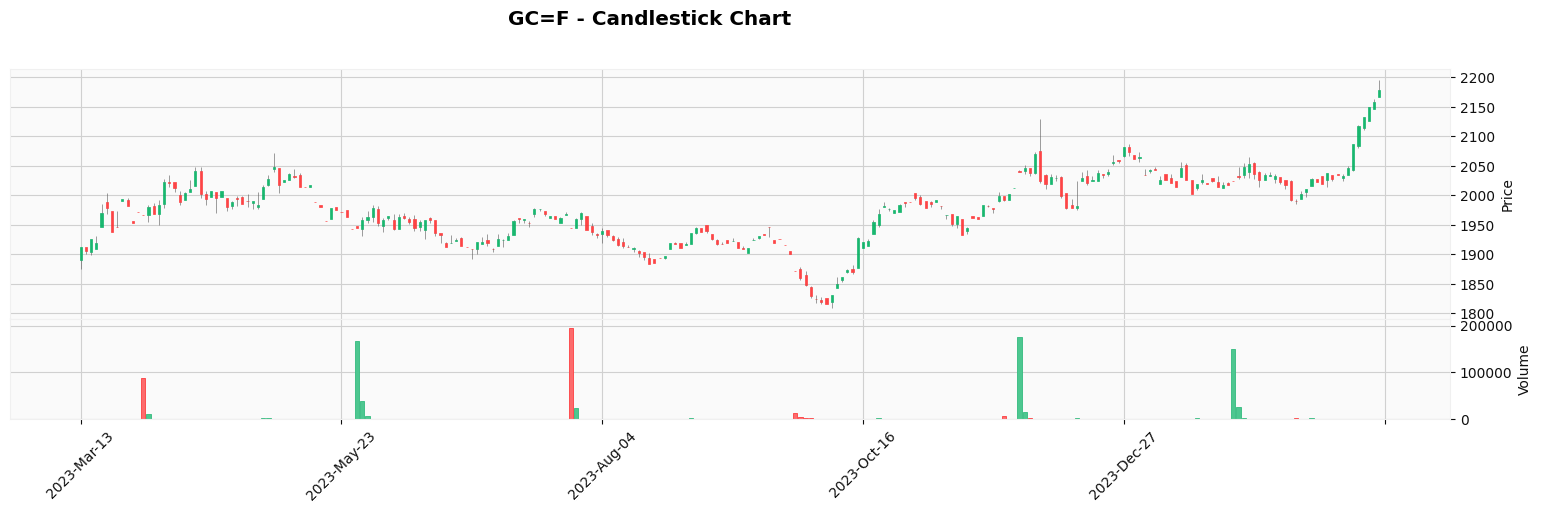

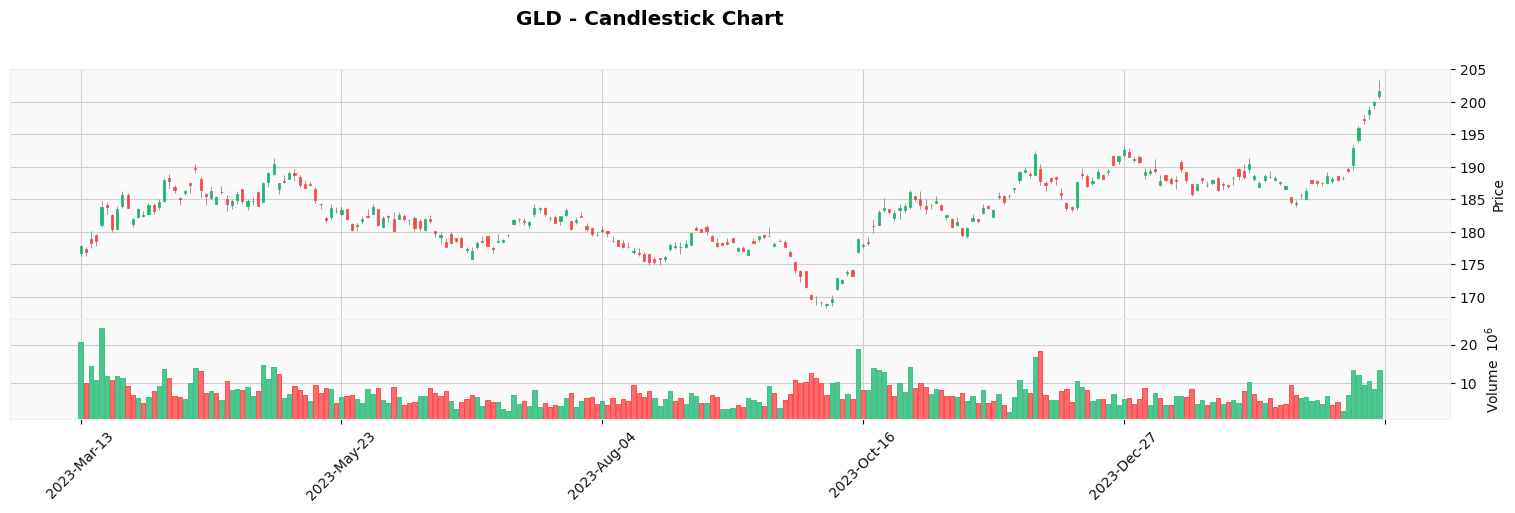

In [3]:
Gold_Futures = data[tickers[0]] # GC=F
Gold_ETF = data[tickers[1]]     # GLD

strat['close_price_GCF'] = Gold_Futures["Close"]
strat['close_price_GLD'] = Gold_ETF["Close"]

mpf.plot(
    data=Gold_Futures.head(250),
    type="candle",
    style="yahoo",
    figsize=(20, 5),
    volume=True,
    title=f"{tickers[0]} - Candlestick Chart"
    )

mpf.plot(
    data=Gold_ETF.head(250),
    type="candle",
    style="yahoo",
    figsize=(20, 5),
    volume=True,
    title=f"{tickers[1]} - Candlestick Chart"
    )

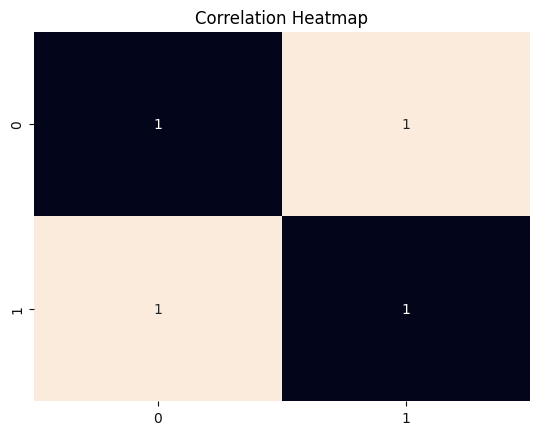

In [ ]:
coef = np.corrcoef((Gold_ETF["Close"],Gold_Futures["Close"]))

names = ["GLD","GC=F"]

plt.figure()
plt.title("Correlation Heatmap")
sns.heatmap(
    coef.tolist(),
    cbar=False,
    annot = True,
    cmap="rocket_r",
    xticklabels=names, 
    yticklabels=names)

plt.grid(False)
plt.show()

In [4]:
log_futures = np.log(Gold_Futures["Close"])
log_etf = np.log(Gold_ETF["Close"])

strat["log_price_GCF"] = log_futures
strat["log_price_GLD"] = log_etf

X = log_futures.values.reshape(-1, 1)
y = log_etf.values.reshape(-1, 1)

reg = LinearRegression().fit(X,y)

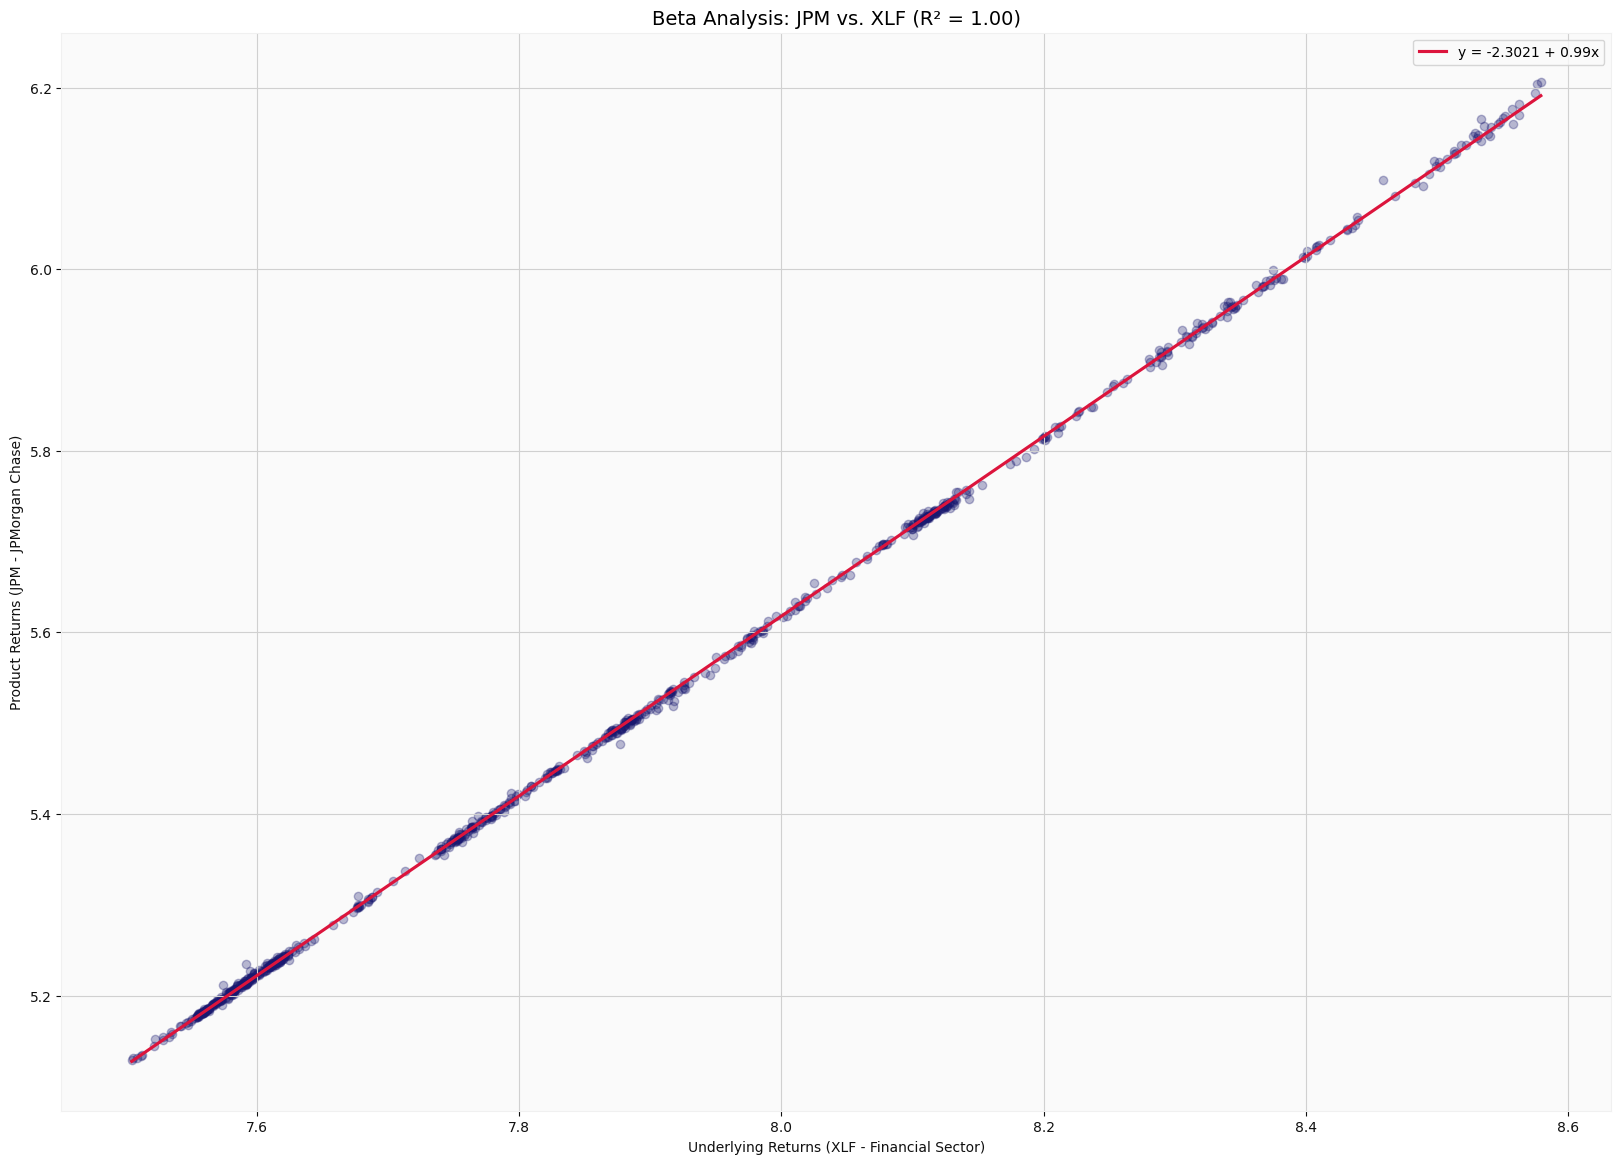

In [5]:
beta = reg.coef_.item()
alpha = reg.intercept_.item()
r_squared = reg.score(X, y)

plt.figure(figsize=(20,14))
sns.regplot(x=X, 
            y=y, 
            scatter_kws={'alpha': 0.3, 'color': 'midnightblue'}, 
            line_kws={'color': 'crimson', 'label': f'y = {alpha:.4f} + {beta:.2f}x'})

plt.title(f"Beta Analysis: JPM vs. XLF (R² = {r_squared:.2f})", fontsize=14)
plt.xlabel("Underlying Returns (XLF - Financial Sector)")
plt.ylabel("Product Returns (JPM - JPMorgan Chase)")
plt.legend()
plt.show()

# Spread

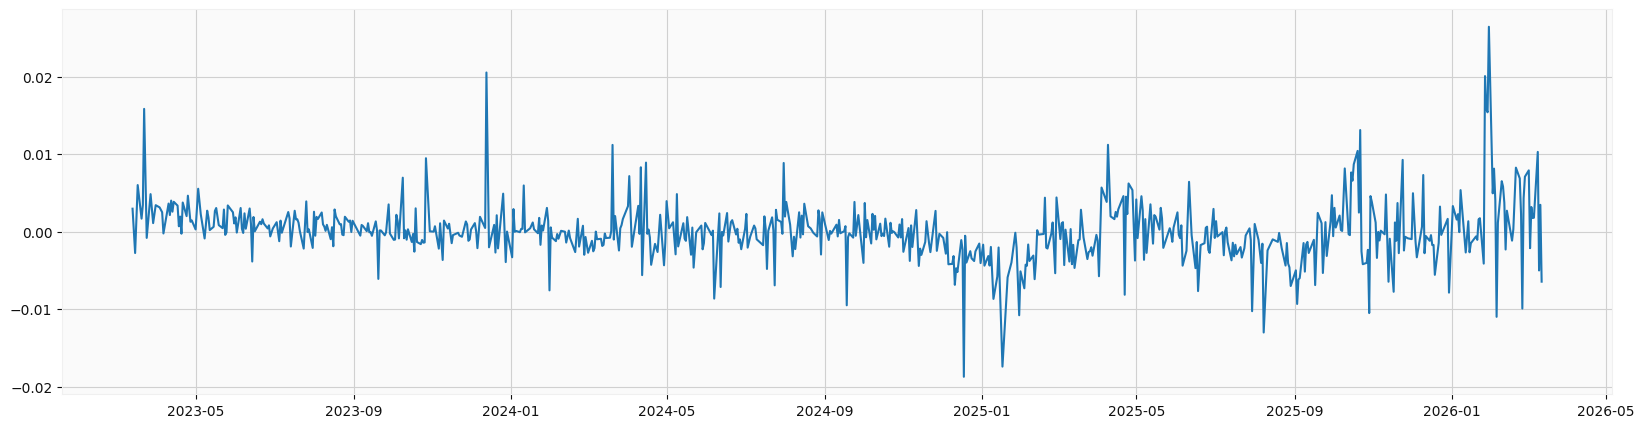

In [6]:
spread = log_etf - (beta * log_futures + alpha)
strat["spread"] = spread

fig = plt.figure(figsize=(20,5))
plt.plot(spread)
plt.show()

In [7]:
p_value = ts.adfuller(spread.dropna(), autolag='AIC')[1]

if p_value < 0.05:
    print(f"Stationary Spread => Cointegration is likely. (p-value: {p_value:.4f})")
else:
    print(f"Non-Stationary Spread => No evidence of cointegration. (p-value: {p_value:.4f})")

Stationary Spread => Cointegration is likely. (p-value: 0.0024)


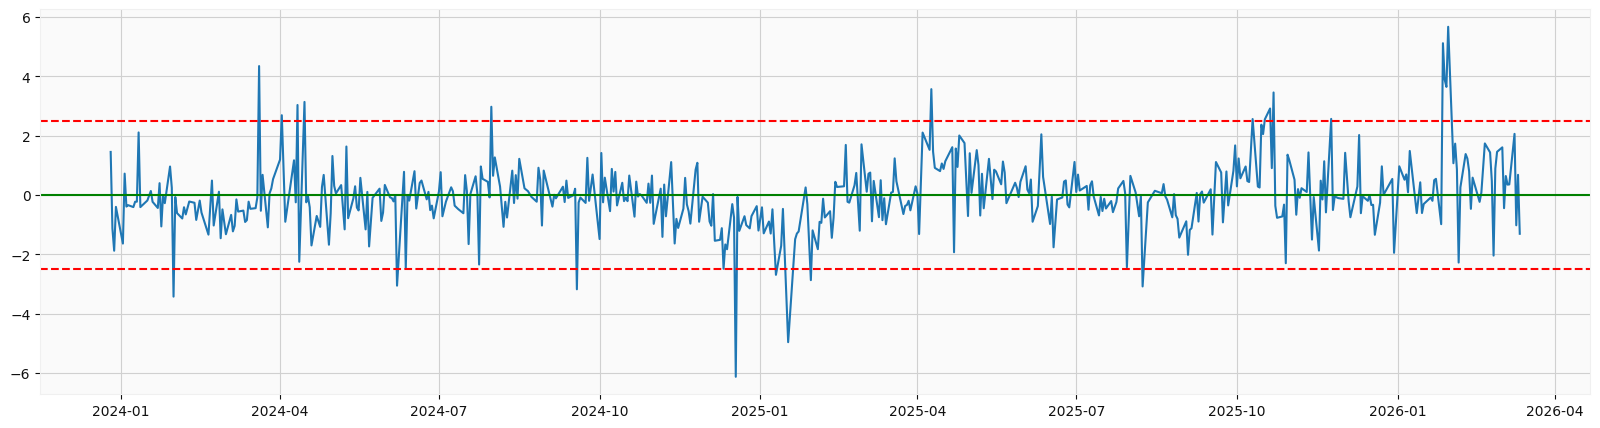

In [8]:
window = 200
rolling_mean_spread = spread.rolling(window=window).mean()
rolling_std_spread = spread.rolling(window=window).std()

z_score = ( spread - rolling_mean_spread) / rolling_std_spread 
z_score.rename()

strat["score"] = z_score

plt.figure(figsize=(20,5))
plt.plot(z_score)
plt.axhline(2.5, color='red', linestyle='--', label='Overvalued (+2σ)')
plt.axhline(0, color='green', linestyle='-')
plt.axhline(-2.5, color='red', linestyle='--', label='Undervalued (-2σ)')
plt.show()

In [12]:
strat["trade_signals"] = np.nan
strat.loc[z_score > 1.5, "trade_signals"] = -1
strat.loc[z_score < -1.5, "trade_signals"] = 1
strat.loc[z_score.abs() < 0.09, "trade_signals"] = 0

strat["trade_signals"] = strat["trade_signals"].ffill().fillna(0)

<Axes: xlabel='Date'>

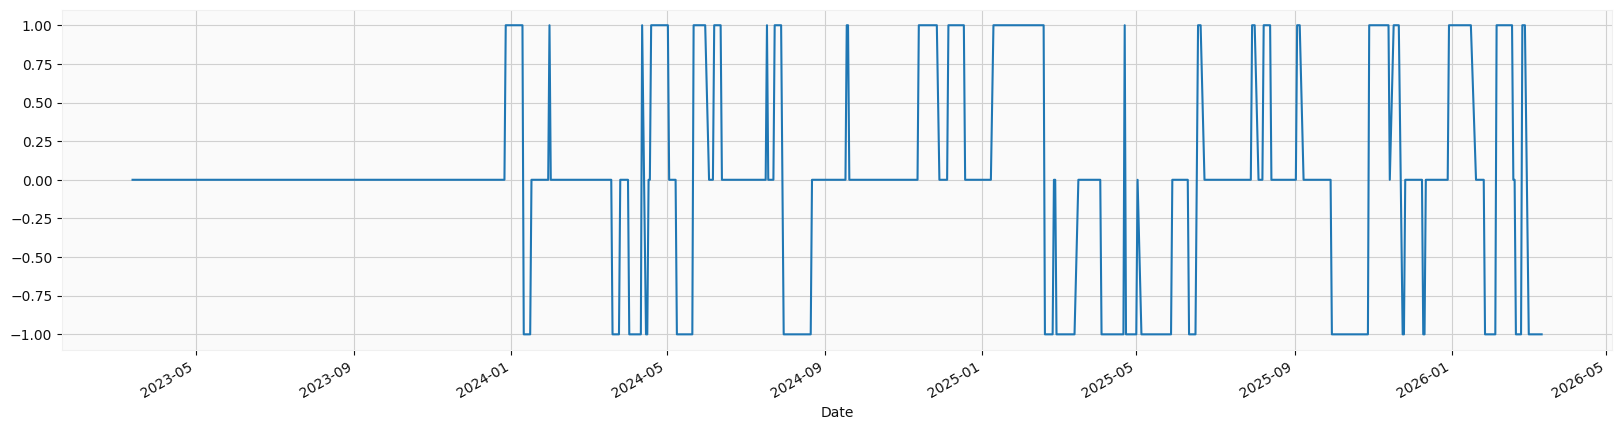

In [13]:
strat['trade_signals'].plot(figsize=(20,5))

In [ ]:
plot_df = data['GC=F'][['Open', 'High', 'Low', 'Close', 'Volume']]

exit_mask = (strat["trade_signals"] == 0) & (strat["trade_signals"].shift(1) != 0)
buy_entry = (strat["trade_signals"] == 1) & (strat["trade_signals"].shift(1) != 1)
sell_entry = (strat["trade_signals"] == -1) & (strat["trade_signals"].shift(1) != -1)

buy_signals = np.where(buy_entry, plot_df["Low"] * 0.98, np.nan)
sell_signals = np.where(sell_entry, plot_df["High"] * 1.02, np.nan)
withdraw_signals = np.where(exit_mask, plot_df["Close"], np.nan)

def plot_interactive(window_size):
    df_slice = plot_df.iloc[-window_size:]
    buy_slice = buy_signals[-window_size:]
    sell_slice = sell_signals[-window_size:]
    withdraw_slice = withdraw_signals[-window_size:]
    
    apds = [
        mpf.make_addplot(buy_slice, type='scatter', markersize=100, marker='^', color='green'),
        mpf.make_addplot(sell_slice, type='scatter', markersize=100, marker='v', color='red'),
        mpf.make_addplot(withdraw_slice, type='scatter', markersize=50, marker='o', color='grey')
    ]
    
    mpf.plot(
        df_slice, 
        type='candle', 
        style='yahoo', 
        addplot=apds,
        figsize=(18, 6), 
        title=f"{tickers[0]} - Lookback: {window_size} days",
        warn_too_much_data=1000000000
    )

interact(
    plot_interactive, 
    window_size=IntSlider(
        min=150, 
        max=len(plot_df), 
        step=5, 
        value=100, 
        description='Days:'
    )
)

interactive(children=(IntSlider(value=150, description='Days:', max=753, min=150, step=5), Output()), _dom_cla…

<function __main__.plot_interactive(window_size)>